# 🛰️ V7 — Sentinel-2 Data Quality Sanity Check

## Purpose
**Before committing to complex training (RoadGIE, FocusMIM, teacher-student etc.),
this notebook answers one question: Is the Sentinel-2 dataset good enough to learn from?**

| Design Choice | Reason |
|---------------|--------|
| **Model** | `smp.DeepLabV3Plus` with `resnet34` encoder (ImageNet pretrained) — proven, fast baseline |
| **No FocusMIM** | Want to see raw dataset signal without any augmentation tricks |
| **No Custom Architecture** | Remove all complexity variables — isolate dataset quality |
| **15 Epochs only** | Quick check — not a full training run |
| **Standard augmentation only** | Flip/rotate — nothing exotic |

### ✅ If v7 achieves Val IoU > 0.30 in 15 epochs → dataset is learnable → proceed to v6
### ❌ If v7 stays flat / under 0.15 → dataset has labeling/alignment issues → fix data first


## ⚙️ 1. Setup & Imports


In [36]:
import sys, subprocess
# Install smp if not available
try:
    import segmentation_models_pytorch as smp
    print(f'[OK] smp version: {smp.__version__}')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'segmentation-models-pytorch'])
    import segmentation_models_pytorch as smp
    print('[OK] smp installed and imported.')

import os, gc, random, glob, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
def set_seed(s=SEED):
    random.seed(s); os.environ['PYTHONHASHSEED'] = str(s)
    np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed()

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'
print(f'[INFO] Device: {device} | AMP: {USE_AMP}')
if device.type == 'cuda':
    print(f'[INFO] GPU : {torch.cuda.get_device_name(0)}')
    print(f'[INFO] VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

try:
    def autocast():    return torch.amp.autocast('cuda', enabled=USE_AMP)
    def make_scaler(): return torch.amp.GradScaler('cuda', enabled=USE_AMP)
except AttributeError:
    def autocast():    return torch.cuda.amp.autocast(enabled=USE_AMP)
    def make_scaler(): return torch.cuda.amp.GradScaler(enabled=USE_AMP)

print('[OK] Setup complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00
[OK] smp installed and imported.
[INFO] Device: cuda | AMP: True
[INFO] GPU : Tesla T4
[INFO] VRAM: 15.6 GB
[OK] Setup complete.


## 📁 2. Find Sentinel-2 Dataset


In [37]:
def find_sentinel2_dirs():
    EXACT_KAGGLE_IMG  = '/kaggle/input/datasets/asmitsinghbisht/sentinal-2/images_enhanced_png/images_enhanced_png'
    EXACT_KAGGLE_MASK = '/kaggle/input/datasets/asmitsinghbisht/sentinal-2/masks_png/masks_png'
    if os.path.exists(EXACT_KAGGLE_IMG) and os.path.exists(EXACT_KAGGLE_MASK):
        print(f'[DATASET] Kaggle Images : {EXACT_KAGGLE_IMG}')
        print(f'[DATASET] Kaggle Masks  : {EXACT_KAGGLE_MASK}')
        return EXACT_KAGGLE_IMG, EXACT_KAGGLE_MASK

    img_subnames  = [
        os.path.join('images_enhanced_png', 'images_enhanced_png'),
        'images_enhanced_png', 'images_enhanced',
        'images', 'image', 'img', 'sat', 'rgb'
    ]
    mask_subnames = [
        os.path.join('masks_png', 'masks_png'),
        'masks_png', 'masks', 'mask', 'gt', 'labels', 'label'
    ]
    search_roots = [
        '/kaggle/input/datasets/asmitsinghbisht/sentinal-2',
        '/kaggle/input/sentinal-2/sentinal-2',
        '/kaggle/input/sentinal-2',
        '/kaggle/input/sentinel-2',
        './sentinal-2', './sentinel-2', './dataset-Road-Sentinel2',
        './', '../',
        r'C:\Users\Asmit Singh Bisht\OneDrive\ドキュメント\Road Inteligence',
    ]
    for root in search_roots:
        if not os.path.exists(root): continue
        img_dirs  = [d for d in [os.path.join(root, n) for n in img_subnames]  if os.path.isdir(d)]
        mask_dirs = [d for d in [os.path.join(root, n) for n in mask_subnames] if os.path.isdir(d)]
        if img_dirs and mask_dirs:
            print(f'[DATASET] Images : {img_dirs[0]}')
            print(f'[DATASET] Masks  : {mask_dirs[0]}')
            return img_dirs[0], mask_dirs[0]

    for root in ['/kaggle/input', '.', '..']:
        if not os.path.exists(root): continue
        found_imgs  = glob.glob(os.path.join(root, '**', 'images_enhanced_png'), recursive=True)
        found_masks = glob.glob(os.path.join(root, '**', 'masks_png'), recursive=True)
        if found_imgs and found_masks:
            return sorted(found_imgs, key=len, reverse=True)[0], sorted(found_masks, key=len, reverse=True)[0]

    raise FileNotFoundError('Cannot find Sentinel-2 folders. Set IMG_DIR / MASK_DIR manually.')

IMG_DIR, MASK_DIR = find_sentinel2_dirs()

# ── Pair matching ──────────────────────────────────────────────────────────
def match_pairs(img_dir, mask_dir):
    exts = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
    all_imgs  = sorted([p for p in glob.glob(os.path.join(img_dir,  '**', '*'), recursive=True) if p.lower().endswith(exts)])
    all_masks = sorted([p for p in glob.glob(os.path.join(mask_dir, '**', '*'), recursive=True) if p.lower().endswith(exts)])
    mask_dict = {}
    for m in all_masks:
        stem = Path(m).stem.lower().replace('_mask','').replace('_gt','').replace('_label','').replace('_png','')
        mask_dict[stem] = m
    pairs = []
    for ip in all_imgs:
        stem = Path(ip).stem.lower().replace('_sat','').replace('_image','').replace('_enhanced','').replace('_png','')
        if stem in mask_dict:
            pairs.append((ip, mask_dict[stem]))
        else:
            cand = os.path.join(mask_dir, os.path.basename(ip))
            if os.path.exists(cand): pairs.append((ip, cand))
    print(f'[DATASET] Matched {len(pairs)} image-mask pairs.')
    return pairs

pairs = match_pairs(IMG_DIR, MASK_DIR)
assert len(pairs) > 0, 'No pairs found! Check IMG_DIR and MASK_DIR paths.'

[DATASET] Kaggle Images : /kaggle/input/datasets/asmitsinghbisht/sentinal-2/images_enhanced_png/images_enhanced_png
[DATASET] Kaggle Masks  : /kaggle/input/datasets/asmitsinghbisht/sentinal-2/masks_png/masks_png
[DATASET] Matched 5634 image-mask pairs.


## 🔍 3. Quick Dataset Sanity Visualisation
Check: are images and masks aligned? Do masks have road pixels?


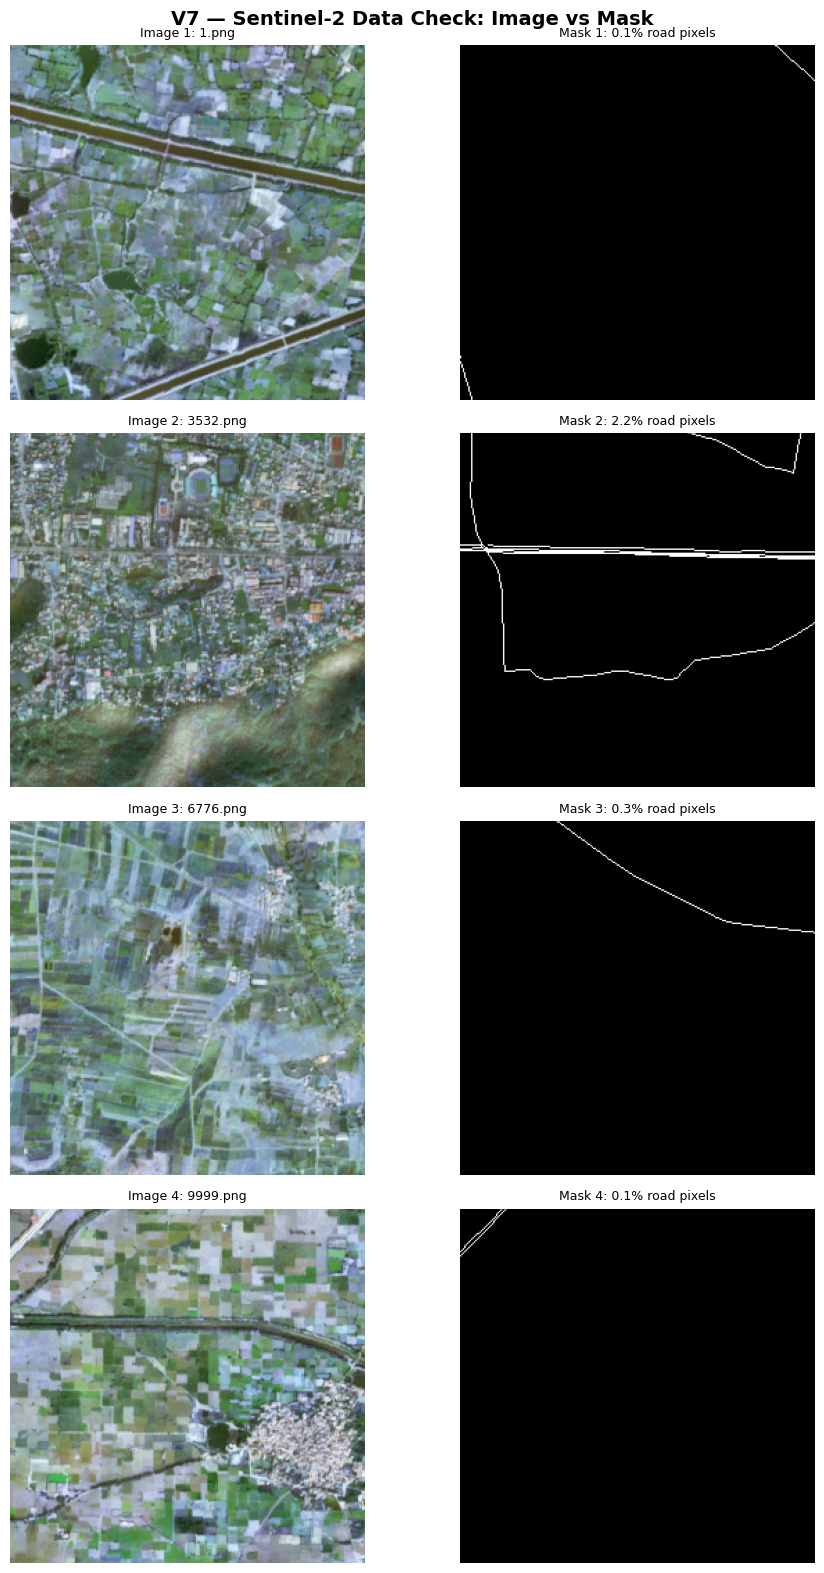

[STATS] Road pixel % across 4 samples: min=0.09%, max=2.22%, mean=0.67%

[CHECKING] Scanning all masks for road pixel content...
[STATS] Total pairs scanned: 5634
[STATS] Road pixel %  —  min: 0.00%  |  mean: 0.65%  |  max: 5.38%
[STATS] Masks with >0% road: 5382 / 5634
[STATS] Masks with <0.5% road (nearly empty): 3017
[WARNING] Very low average road density. Check if masks are binarized correctly.


In [38]:
def show_samples(pairs, n=4, title='Sentinel-2 Samples'):
    n = min(n, len(pairs))
    fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
    if n == 1: axes = np.expand_dims(axes, 0)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    road_pcts = []
    for i, (ip, mp) in enumerate(pairs[:n]):
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        road_pct = (msk > 128).mean() * 100
        road_pcts.append(road_pct)
        axes[i,0].imshow(img)
        axes[i,0].set_title(f'Image {i+1}: {Path(ip).name}', fontsize=9)
        axes[i,0].axis('off')
        axes[i,1].imshow(msk, cmap='gray')
        axes[i,1].set_title(f'Mask {i+1}: {road_pct:.1f}% road pixels', fontsize=9)
        axes[i,1].axis('off')
    plt.tight_layout(); plt.show()
    print(f'[STATS] Road pixel % across {n} samples: min={min(road_pcts):.2f}%, max={max(road_pcts):.2f}%, mean={np.mean(road_pcts):.2f}%')
    return road_pcts

# Sample 4 evenly spread across dataset
sample_idxs = np.linspace(0, len(pairs)-1, 4, dtype=int)
sample_pairs = [pairs[i] for i in sample_idxs]
road_pcts = show_samples(sample_pairs, n=4, title='V7 — Sentinel-2 Data Check: Image vs Mask')

# Overall road pixel stats across ALL masks
print('\n[CHECKING] Scanning all masks for road pixel content...')
all_road_pcts = []
for _, mp in pairs:
    m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    if m is not None:
        all_road_pcts.append((m > 128).mean() * 100)
all_road_pcts = np.array(all_road_pcts)
print(f'[STATS] Total pairs scanned: {len(all_road_pcts)}')
print(f'[STATS] Road pixel %  —  min: {all_road_pcts.min():.2f}%  |  mean: {all_road_pcts.mean():.2f}%  |  max: {all_road_pcts.max():.2f}%')
print(f'[STATS] Masks with >0% road: {(all_road_pcts > 0).sum()} / {len(all_road_pcts)}')
print(f'[STATS] Masks with <0.5% road (nearly empty): {(all_road_pcts < 0.5).sum()}')
if all_road_pcts.mean() < 1.0:
    print('[WARNING] Very low average road density. Check if masks are binarized correctly.')
else:
    print('[OK] Road pixel density looks reasonable for training.')

## 🗂️ 4. Train/Val/Test Split & DataLoader
No FocusMIM. Standard augmentations only (flip, rotate).


In [39]:
IMG_SIZE = 512
BS       = 4   # Larger batch since model is simpler
NW       = 2 if os.name == 'posix' else 0
MEAN     = (0.485, 0.456, 0.406)
STD      = (0.229, 0.224, 0.225)

tr_val, te = train_test_split(pairs, test_size=0.10, random_state=SEED)
tr, va     = train_test_split(tr_val, test_size=0.1111, random_state=SEED)
print(f'[SPLIT] Train: {len(tr)} | Val: {len(va)} | Test: {len(te)}')

# ── Transforms (NO FocusMIM) ──────────────────────────────────────────────
tr_tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4,
                       border_mode=cv2.BORDER_CONSTANT),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])
va_tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

def binarize(m):
    if m.ndim == 3: m = m[:,:,0]
    return (m > 128).astype(np.float32)

class Sentinel2DS(Dataset):
    def __init__(self, pairs, tfm=None):
        self.pairs = pairs; self.tfm = tfm

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        msk = binarize(cv2.imread(mp, cv2.IMREAD_GRAYSCALE))
        if self.tfm:
            aug = self.tfm(image=img, mask=msk)
            img, msk = aug['image'], aug['mask']
        return img, msk.unsqueeze(0)

tr_ds = Sentinel2DS(tr, tr_tfm)
va_ds = Sentinel2DS(va, va_tfm)
te_ds = Sentinel2DS(te, va_tfm)
tr_ld = DataLoader(tr_ds, batch_size=BS, shuffle=True,  num_workers=NW, pin_memory=True, drop_last=True,  persistent_workers=(NW>0))
va_ld = DataLoader(va_ds, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=True, drop_last=False, persistent_workers=(NW>0))
te_ld = DataLoader(te_ds, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=True, drop_last=False, persistent_workers=(NW>0))
print(f'[OK] DataLoaders ready. BS={BS} | train_steps={len(tr_ld)} | val_steps={len(va_ld)}')

[SPLIT] Train: 4506 | Val: 564 | Test: 564
[OK] DataLoaders ready. BS=4 | train_steps=1126 | val_steps=141


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 🏗️ 5. Baseline Model — smp.DeepLabV3Plus (ResNet-34, ImageNet)
Proven Atrous Spatial Pyramid Pooling (ASPP) architecture for multi-scale road feature extraction.


In [40]:
model = smp.DeepLabV3Plus(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    activation      = None,   # Raw logits — we apply sigmoid in loss/metrics
)
model = model.to(device)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'[MODEL] smp.DeepLabV3Plus / resnet34 / imagenet')
print(f'[MODEL] Total params   : {total/1e6:.2f} M')
print(f'[MODEL] Trainable params: {train_/1e6:.2f} M')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[MODEL] smp.DeepLabV3Plus / resnet34 / imagenet
[MODEL] Total params   : 22.44 M
[MODEL] Trainable params: 22.44 M


## 🎯 6. Loss, Metrics & Optimizer


In [41]:
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__(); self.s = smooth
    def forward(self, logits, y):
        p = torch.sigmoid(logits)
        num = 2.0*(p*y).sum(dim=(2,3))
        den = (p**2).sum(dim=(2,3)) + (y**2).sum(dim=(2,3)) + self.s
        return 1.0 - (num/den).mean()

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = SoftDiceLoss()
    def forward(self, logits, y):
        return 0.5*self.bce(logits, y) + 0.5*self.dice(logits, y)

def metrics(logits, y, thr=0.5):
    p  = (torch.sigmoid(logits) > thr).float()
    tp = (p*y).sum(dim=(2,3));   fp = (p*(1-y)).sum(dim=(2,3))
    fn = ((1-p)*y).sum(dim=(2,3)); e = 1e-6
    return (
        ((tp+e)/(tp+fp+fn+e)).mean().item(),       # IoU
        ((2*tp+e)/(2*tp+fp+fn+e)).mean().item(),   # Dice/F1
        ((tp+e)/(tp+fp+e)).mean().item(),           # Precision
        ((tp+e)/(tp+fn+e)).mean().item(),           # Recall
    )

criterion = CombinedLoss()
EPOCHS    = 15
LR        = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = make_scaler()
print(f'[OK] Loss & optimizer ready. LR={LR}, Epochs={EPOCHS}')

[OK] Loss & optimizer ready. LR=0.0001, Epochs=15


## 🔄 7. Training Loop


In [42]:
CKPT    = 'v7_sentinel2_baseline.pth'
best_iou = 0.0
history  = {'tr_loss':[], 'va_loss':[], 'va_iou':[], 'va_dice':[], 'va_prec':[], 'va_rec':[]}

for ep in range(EPOCHS):
    ep1 = ep + 1

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    tr_loss = 0.0
    pbar = tqdm(tr_ld, desc=f'Ep {ep1}/{EPOCHS} [train]')
    for imgs, msks in pbar:
        imgs, msks = imgs.to(device), msks.to(device)
        optimizer.zero_grad()
        with autocast():
            loss = criterion(model(imgs), msks)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        tr_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    scheduler.step()
    avg_tr = tr_loss / len(tr_ld)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    va_loss = v_iou = v_dice = v_prec = v_rec = 0.0
    with torch.no_grad():
        for imgs, msks in tqdm(va_ld, desc=f'Ep {ep1}/{EPOCHS} [val]'):
            imgs, msks = imgs.to(device), msks.to(device)
            with autocast():
                logits   = model(imgs)
                va_loss += criterion(logits, msks).item()
            iou, dice, prec, rec = metrics(logits, msks)
            v_iou+=iou; v_dice+=dice; v_prec+=prec; v_rec+=rec
    n = len(va_ld)
    avg_va, ai, ad, ap, ar = va_loss/n, v_iou/n, v_dice/n, v_prec/n, v_rec/n

    history['tr_loss'].append(avg_tr); history['va_loss'].append(avg_va)
    history['va_iou'].append(ai);      history['va_dice'].append(ad)
    history['va_prec'].append(ap);     history['va_rec'].append(ar)

    print(f'Ep {ep1:02d}/{EPOCHS} | tr_loss={avg_tr:.4f} | va_loss={avg_va:.4f} | IoU={ai:.4f} | Dice={ad:.4f} | Prec={ap:.4f} | Rec={ar:.4f}')

    if ai > best_iou:
        best_iou = ai
        torch.save({'epoch': ep1, 'model_state_dict': model.state_dict(),
                    'best_val_iou': best_iou, 'history': history}, CKPT)
        print(f'  >>> Best checkpoint saved. Val IoU: {best_iou:.4f}')

print(f'\n[DONE] Training complete. Best Val IoU: {best_iou:.4f}')

Ep 1/15 [train]:   0%|          | 0/1126 [00:00<?, ?it/s]

Ep 1/15 [val]:   0%|          | 0/141 [00:00<?, ?it/s]

Ep 01/15 | tr_loss=0.4457 | va_loss=0.3542 | IoU=0.1648 | Dice=0.2604 | Prec=0.2730 | Rec=0.3694
  >>> Best checkpoint saved. Val IoU: 0.1648


Ep 2/15 [train]:   0%|          | 0/1126 [00:00<?, ?it/s]

Ep 2/15 [val]:   0%|          | 0/141 [00:00<?, ?it/s]

...

Ep 14/15 [val]:   0%|          | 0/141 [00:00<?, ?it/s]

Ep 14/15 | tr_loss=0.2749 | va_loss=0.2973 | IoU=0.2679 | Dice=0.3937 | Prec=0.4291 | Rec=0.5133


Ep 15/15 [train]:   0%|          | 0/1126 [00:00<?, ?it/s]

Ep 15/15 [val]:   0%|          | 0/141 [00:00<?, ?it/s]

Ep 15/15 | tr_loss=0.2734 | va_loss=0.2958 | IoU=0.2703 | Dice=0.3956 | Prec=0.4280 | Rec=0.5121

[DONE] Training complete. Best Val IoU: 0.2785


## 📊 8. Results: Training Curves + Data Quality Verdict


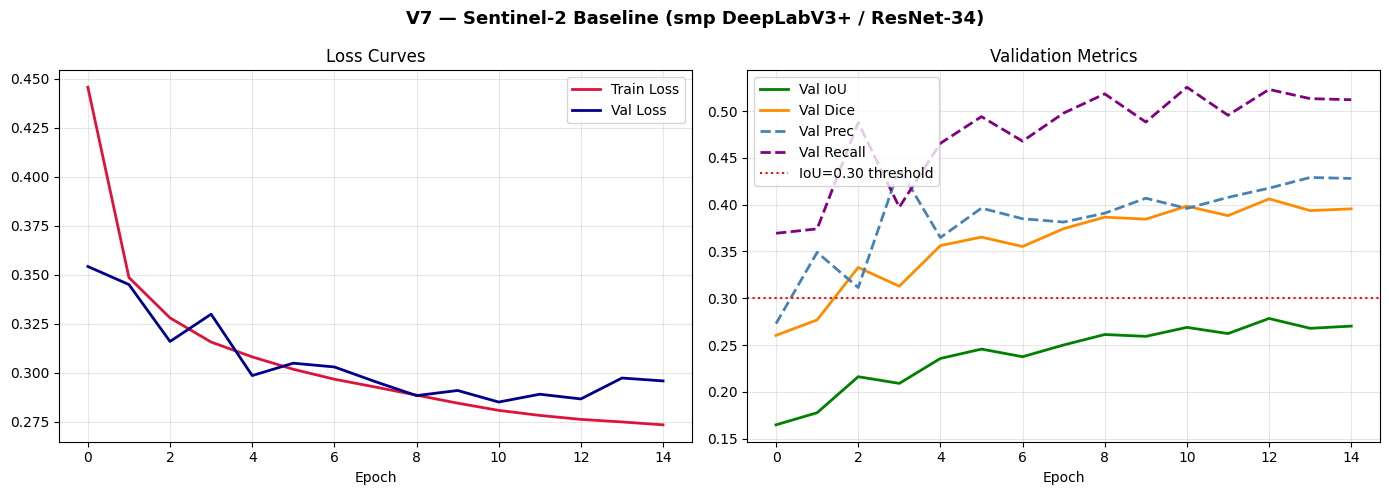


  V7 DATA QUALITY VERDICT
  Best Val IoU   : 0.2785
  Final Val IoU  : 0.2703
  IoU trend      : +0.1055 over 15 epochs

  ⚠️  VERDICT: CAUTIOUS — Weak but non-zero signal detected.
     → Check mask alignment visually. Try more epochs or larger dataset.
     → Consider data cleaning before running V6.


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('V7 — Sentinel-2 Baseline (smp DeepLabV3+ / ResNet-34)', fontsize=13, fontweight='bold')

axes[0].plot(history['tr_loss'], label='Train Loss', color='crimson',  lw=2)
axes[0].plot(history['va_loss'], label='Val Loss',   color='darkblue', lw=2)
axes[0].set_title('Loss Curves'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['va_iou'],  label='Val IoU',    color='green',      lw=2)
axes[1].plot(history['va_dice'], label='Val Dice',   color='darkorange', lw=2)
axes[1].plot(history['va_prec'], label='Val Prec',   color='steelblue',  lw=2, ls='--')
axes[1].plot(history['va_rec'],  label='Val Recall', color='purple',     lw=2, ls='--')
axes[1].axhline(y=0.30, color='red', ls=':', lw=1.5, label='IoU=0.30 threshold')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Verdict ───────────────────────────────────────────────────────────────
final_iou = history['va_iou'][-1]
best_iou_hist = max(history['va_iou'])
trend = history['va_iou'][-1] - history['va_iou'][0]   # positive = learning

print('\n' + '='*60)
print('  V7 DATA QUALITY VERDICT')
print('='*60)
print(f'  Best Val IoU   : {best_iou_hist:.4f}')
print(f'  Final Val IoU  : {final_iou:.4f}')
print(f'  IoU trend      : {trend:+.4f} over {EPOCHS} epochs')
print()

if best_iou_hist >= 0.35:
    print('  ✅ VERDICT: PROCEED  — Strong signal. Dataset is learnable.')
    print('     → Go ahead with V6 (RoadGIE + phased freezing + FocusMIM)')
elif best_iou_hist >= 0.20:
    print('  ⚠️  VERDICT: CAUTIOUS — Weak but non-zero signal detected.')
    print('     → Check mask alignment visually. Try more epochs or larger dataset.')
    print('     → Consider data cleaning before running V6.')
elif trend > 0.02:
    print('  ⚠️  VERDICT: STILL LEARNING — IoU < 0.20 but positive trend.')
    print('     → Run for more epochs before deciding.')
else:
    print('  ❌ VERDICT: DATA ISSUE — Model not learning from Sentinel-2 data.')
    print('     → Check: mask binarization, image-mask pairing, label quality.')
    print('     → Do NOT proceed to V6 until data issues are resolved.')
print('='*60)

## 🔬 9. Visual Predictions on Test Set


[OK] Best checkpoint loaded for inference.


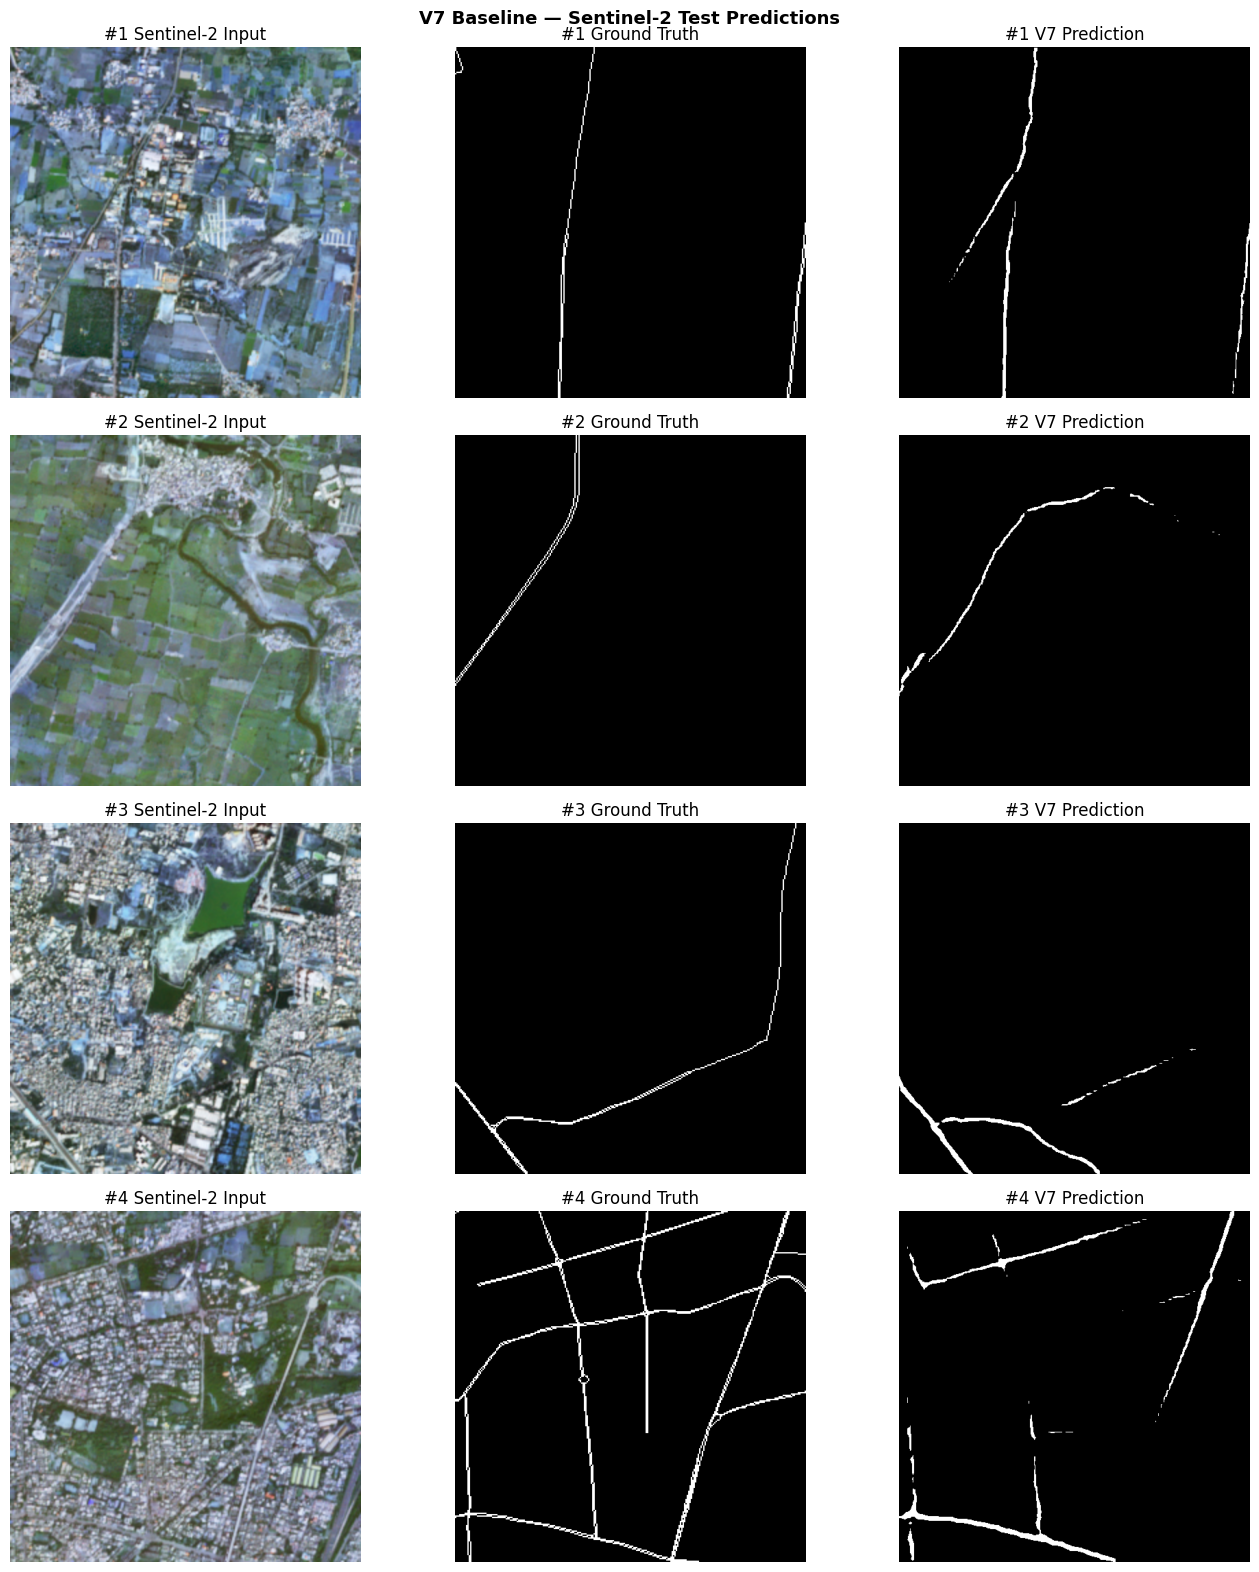

In [44]:
# Load best checkpoint
if os.path.exists(CKPT):
    model.load_state_dict(torch.load(CKPT, map_location=device)['model_state_dict'])
    print('[OK] Best checkpoint loaded for inference.')

model.eval()
imgs_b, msks_b, preds_b = None, None, None
with torch.no_grad():
    for imgs, msks in te_ld:
        with autocast():
            preds = (torch.sigmoid(model(imgs.to(device))) > 0.5).cpu().numpy()
        imgs_b, msks_b, preds_b = imgs, msks, preds
        break

N = min(4, len(imgs_b))
fig, axes = plt.subplots(N, 3, figsize=(14, 4*N))
if N == 1: axes = np.expand_dims(axes, 0)
fig.suptitle('V7 Baseline — Sentinel-2 Test Predictions', fontsize=13, fontweight='bold')
for i in range(N):
    img_np = imgs_b[i].permute(1,2,0).numpy()
    img_np = (img_np * np.array(STD) + np.array(MEAN)).clip(0, 1)
    axes[i,0].imshow(img_np)
    axes[i,0].set_title(f'#{i+1} Sentinel-2 Input'); axes[i,0].axis('off')
    axes[i,1].imshow(msks_b[i,0], cmap='gray')
    axes[i,1].set_title(f'#{i+1} Ground Truth');    axes[i,1].axis('off')
    axes[i,2].imshow(preds_b[i,0], cmap='gray')
    axes[i,2].set_title(f'#{i+1} V7 Prediction');   axes[i,2].axis('off')
plt.tight_layout(); plt.show()